# 01-The Physics of RAG

In Section 11, we mathematically forced a Foundation Model to follow instructions using Supervised Fine-Tuning (SFT) and Direct Preference Optimization (DPO).

However, standard fine-tuning suffers from a catastrophic architectural flaw: **Static Knowledge**.
If you trained Llama-3 in December 2023, the model mathematically *does not know* what happened in January 2024. Its knowledge is frozen in its matrix weights. If you ask it for current stock prices, or private corporate documents that were not in its training data, the autoregressive engine will suffer a probability collapse and generate highly convincing lies. We call this **Hallucination**.

To solve this without spending millions of dollars re-training the model every single day, we must master **Retrieval-Augmented Generation (RAG)**.

Let's set up our environment to deconstruct the mathematics of Non-Parametric Memory.

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import textwrap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & RAG Environment Ready.")


✅ Systems Architecture & RAG Environment Ready.


# 1. Parametric vs. Non-Parametric Memory

To understand RAG, we must divide Artificial Intelligence into two distinct physical memory systems.

### 1. Parametric Memory (The Brain)

When a model reads the internet during Pre-Training, it mathematically compresses trillions of words into billions of floating-point numbers (Weights and Biases). This is **Parametric Memory**.

* **The Physics**: Information is stored implicitly inside the tensor gradients.
* **The Problem**: Updating Parametric Memory requires Backpropagation. If your company's HR policy changes, you cannot easily "delete" the old policy from the neural network's weights.

### 2. Non-Parametric Memory (The Filing Cabinet)

This is an external database (typically a Vector Database) that sits *outside* the neural network.

* **The Physics**: Information is stored explicitly as raw text and vectors on a hard drive.
* **The Solution**: If your HR policy changes, you simply execute a SQL `DELETE` row and `INSERT` row. The update happens in $O(1)$ time, costing $0.00$.

# 2. The Mathematics of Contextual Conditioning

A standard LLM predicts the next sequence of tokens ($y$) conditioned purely on the user's prompt ($x$).


$$P(y | x) = \prod_{t=1}^{T} P(y_t | y_{<t}, x)$$

If the knowledge required to answer $x$ is not in the Parametric Memory, $P(y|x)$ flattens out, and the model guesses blindly (Hallucination).

**The RAG Equation** fundamentally alters this probability distribution. We introduce a retrieval function $\mathcal{R}$ that searches a vast database corpus $D$ and returns a highly relevant chunk of text $z$.
We then condition the LLM's generation on *both* the user prompt $x$ and the retrieved context $z$:


$$z = \mathcal{R}(x, D)$$

$$P(y | x, z) = \prod_{t=1}^{T} P(y_t | y_{<t}, x, z)$$

By forcing $z$ into the LLM's finite Context Window, the Self-Attention mechanism heavily attends to the retrieved facts, mathematically suppressing hallucinations.

# 3. Architecting the Naive RAG Pipeline

Let's build the raw string-manipulation engine that powers RAG. We will simulate a user asking a question about a private company concept ("Project Quantum"), retrieve a mock document, and engineer the exact System Prompt required to ground the LLM.

In [2]:
# --- 🧠 The Naive RAG Engine ---

# 1. The Non-Parametric Database (Simulated Corpus)
# The LLM was never trained on this data.
KNOWLEDGE_BASE = {
    "doc_001": "The company cafeteria serves pizza on Fridays.",
    "doc_002": "Project Quantum is a highly classified initiative to build a 10,000-GPU cluster in Iceland, set to launch in Q4 2026.",
    "doc_003": "The CEO's name is Sarah Jenkins."
}

# 2. The Retrieval Function (Simulated Dense Search)
def retrieve_context(query: str, top_k: int = 1) -> str:
    """
    Simulates searching a Vector Database. 
    In reality, this uses Cosine Similarity between the query vector and document vectors.
    """
    print(f"🔍 [RETRIEVER] Executing similarity search for: '{query}'")
    # Hardcoded simulation: We assume the math perfectly finds doc_002
    retrieved_chunk = KNOWLEDGE_BASE["doc_002"]
    print(f"📥 [RETRIEVER] Found Context: '{retrieved_chunk}'\n")
    return retrieved_chunk

# 3. The Contextual Injection Prompt
def construct_rag_prompt(user_query: str, retrieved_context: str) -> str:
    """
    This is the mathematical core of RAG. We bind the retrieved knowledge (z)
    and the user query (x) into a single, impenetrable string of text.
    """
    # We use a strict XML-style template to prevent the LLM from confusing 
    # the context with the instructions.
    system_prompt = f"""You are a helpful Enterprise AI assistant. 
You must answer the user's question using ONLY the information provided in the <context> block below. 
If the answer is not contained in the context, you must reply: "I do not have enough information to answer that."
Under no circumstances should you use your pre-trained knowledge to answer.

<context>
{retrieved_context}
</context>

User Question: {user_query}
"""
    return system_prompt

# 4. Executing the Pipeline
user_query = "What is the launch date for Project Quantum?"

# Step A: Retrieve (z)
context_z = retrieve_context(user_query)

# Step B: Inject (x + z)
final_llm_input = construct_rag_prompt(user_query, context_z)

print("--- 📝 The Final LLM Tensor Payload ---")
print(final_llm_input)

print("\n--- 💡 Engineering Insight ---")
print("Notice the strict instructional bounds: 'using ONLY the information provided'. We are actively fighting the LLM's Parametric Memory. If Llama-3 read a sci-fi novel about a 'Project Quantum' during Pre-Training, it will want to talk about time travel. By injecting this strict System Prompt, we mathematically force the Attention Heads to prioritize the text inside the <context> tags over its own frozen weights.")

🔍 [RETRIEVER] Executing similarity search for: 'What is the launch date for Project Quantum?'
📥 [RETRIEVER] Found Context: 'Project Quantum is a highly classified initiative to build a 10,000-GPU cluster in Iceland, set to launch in Q4 2026.'

--- 📝 The Final LLM Tensor Payload ---
You are a helpful Enterprise AI assistant. 
You must answer the user's question using ONLY the information provided in the <context> block below. 
If the answer is not contained in the context, you must reply: "I do not have enough information to answer that."
Under no circumstances should you use your pre-trained knowledge to answer.

<context>
Project Quantum is a highly classified initiative to build a 10,000-GPU cluster in Iceland, set to launch in Q4 2026.
</context>

User Question: What is the launch date for Project Quantum?


--- 💡 Engineering Insight ---
Notice the strict instructional bounds: 'using ONLY the information provided'. We are actively fighting the LLM's Parametric Memory. If Llama-3 rea

# 4. Visualizing the RAG Network Topology

To deeply understand why this architecture scales, let's use Matplotlib to draw the physical data flow of a RAG system. Notice how the heavy LLM is entirely decoupled from the vast knowledge base.

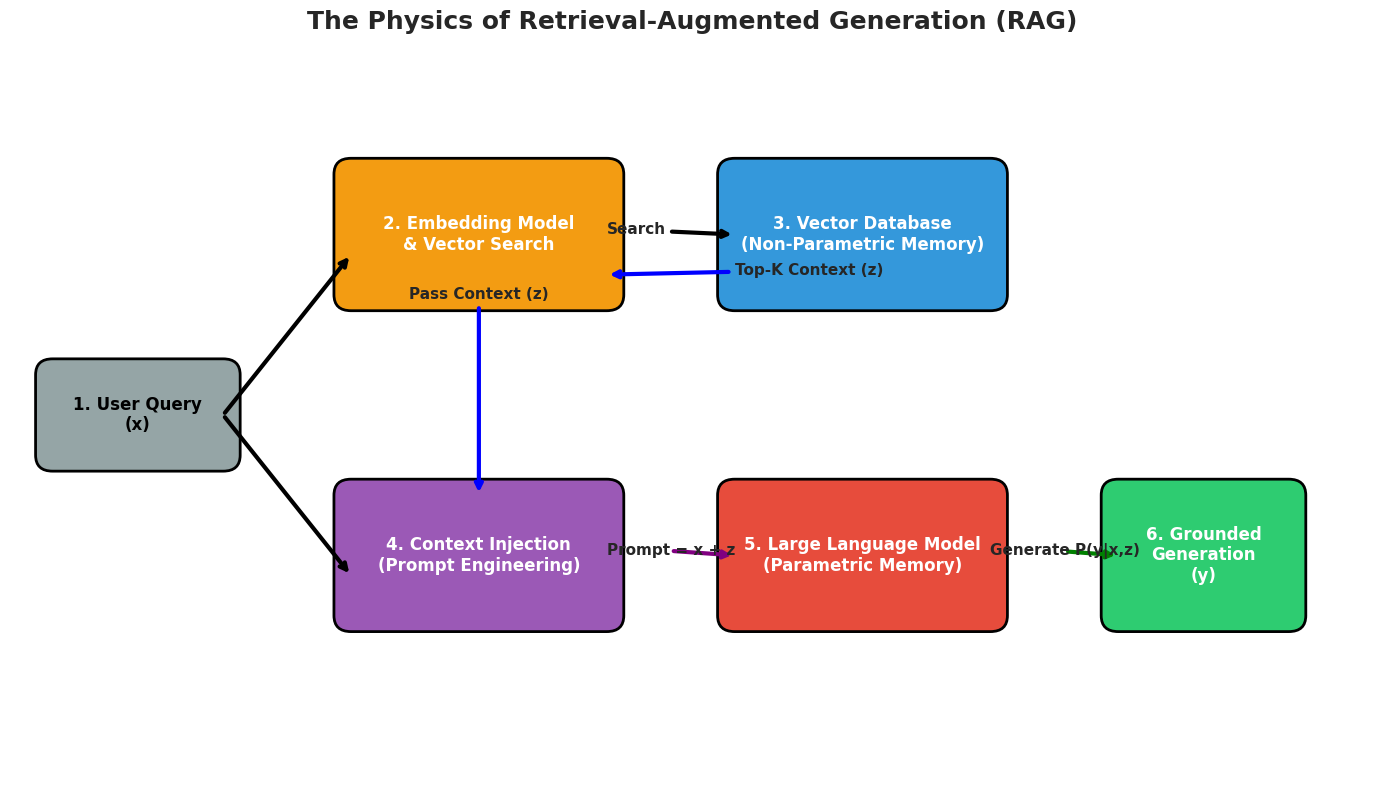

In [3]:
# Visualizing the Enterprise RAG Topology
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("The Physics of Retrieval-Augmented Generation (RAG)", fontsize=18, fontweight='bold')

ax.axis('off')

# Helper function for drawing architectural nodes
def draw_node(ax, x, y, width, height, text, color, text_color="white"):
    rect = patches.FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.2", 
                                  linewidth=2, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', 
            fontsize=12, fontweight='bold', color=text_color)

# Draw the Nodes
# 1. User Input
draw_node(ax, 0.5, 5, 2, 1, "1. User Query\n(x)", "#95a5a6", "black")

# 2. Embedding & Retrieval Engine
draw_node(ax, 4.0, 7, 3, 1.5, "2. Embedding Model\n& Vector Search", "#f39c12")

# 3. Non-Parametric Memory (Vector DB)
draw_node(ax, 8.5, 7, 3, 1.5, "3. Vector Database\n(Non-Parametric Memory)", "#3498db")

# 4. Prompt Construction
draw_node(ax, 4.0, 3, 3, 1.5, "4. Context Injection\n(Prompt Engineering)", "#9b59b6")

# 5. LLM
draw_node(ax, 8.5, 3, 3, 1.5, "5. Large Language Model\n(Parametric Memory)", "#e74c3c")

# 6. Output
draw_node(ax, 13.0, 3, 2, 1.5, "6. Grounded\nGeneration\n(y)", "#2ecc71")


# Draw the Data Flow Arrows
# Query to Retriever
ax.annotate("", xy=(4.0, 7.5), xytext=(2.5, 5.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
# Query to Prompt Builder
ax.annotate("", xy=(4.0, 3.5), xytext=(2.5, 5.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))

# Retriever to Vector DB
ax.annotate("Search", xy=(8.5, 7.75), xytext=(7.0, 7.75), arrowprops=dict(arrowstyle="->", lw=3, color="black"), fontsize=11, fontweight='bold')
# Vector DB to Retriever
ax.annotate("Top-K Context (z)", xy=(7.0, 7.25), xytext=(8.5, 7.25), arrowprops=dict(arrowstyle="->", lw=3, color="blue"), fontsize=11, fontweight='bold')

# Retriever to Prompt Builder
ax.annotate("Pass Context (z)", xy=(5.5, 4.5), xytext=(5.5, 7.0), arrowprops=dict(arrowstyle="->", lw=3, color="blue"), fontsize=11, fontweight='bold', ha='center', va='center')

# Prompt Builder to LLM
ax.annotate("Prompt = x + z", xy=(8.5, 3.75), xytext=(7.0, 3.75), arrowprops=dict(arrowstyle="->", lw=3, color="purple"), fontsize=11, fontweight='bold')

# LLM to Output
ax.annotate("Generate P(y|x,z)", xy=(13.0, 3.75), xytext=(11.5, 3.75), arrowprops=dict(arrowstyle="->", lw=3, color="green"), fontsize=11, fontweight='bold')

plt.xlim(0, 16)
plt.ylim(1, 10)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between an LLM and RAG like **Taking a Bar Exam**:

* **Standard LLM (Closed-Book Exam)**: You sit in a room with a pencil. The proctor asks you to recite the exact wording of an obscure 1982 tax law. You studied it 4 years ago (Pre-Training), but you can't remember the exact wording. You guess. You sound very confident, but you are completely wrong (Hallucination).
* **RAG (Open-Book Exam)**: You sit in the same room, but this time, you have an assistant (The Retriever) and a massive filing cabinet of legal textbooks (The Vector Database). The proctor asks the question ($x$). You send your assistant to the filing cabinet. They find the exact page regarding the 1982 tax law ($z$) and place it on your desk. You read the page and perfectly answer the question. You didn't need to memorize the book; you just needed to know how to read it.